# Очистка датасета `projects_planeta.xlsx` от выбросов

Цель — идентифицировать и удалить выбросы по всем числовым столбцам, сохранить очищенный датасет и датасет с выброшенными строками.

## План
1. Загрузка и обзор данных
2. Идентификация выбросов:
   - Правила бизнес-логики (нулевые / невалидные значения, нереалистичные диапазоны)
   - Одномерные методы: **IQR** (Тьюки, 1.5× и 3×) и **Z-score** (|z| > 3)
   - Многомерный метод: **Isolation Forest**
3. Визуализация (boxplots, histograms, scatterplots) — `seaborn`/`matplotlib`
4. Сводка: маркировка каждой строки флагами, определение итогового флага `is_outlier`
5. Сохранение результатов: `projects_planeta_with_text_cleaned.xlsx` + `projects_planeta_with_text_outliers.xlsx`

## 1. Загрузка и обзор

In [194]:
import pandas as pd

file_path = 'projects_planeta.xlsx'
df = pd.read_excel(file_path)

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# =====================================================================
# Единая тема и словарь русских подписей для всех графиков
# =====================================================================
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    palette="Set2",
)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.labelweight": "regular",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "#cccccc",
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.6,
})

COLOR_PRIMARY = "#2E86AB"
COLOR_SUCCESS = "#06A77D"
COLOR_FAIL    = "#D62246"
COLOR_NEUTRAL = "#7F8C8D"
COLOR_ACCENT  = "#F4A261"

COL_LABELS = {
    "project_key": "ID проекта",
    "card.collectedAmount.value": "Собрано, руб.",
    "card.targetAmount.value": "Цель сбора, руб.",
    "card.daysToFinish": "Дней до окончания",
    "card.author.id": "ID автора",
    "card.author.campaignsAmount": "Кампаний у автора",
    "counts.newsCount": "Число новостей",
    "counts.commentsCount": "Число комментариев",
    "counts.participantsCount": "Число участников",
    "counts.purchasesCount": "Число покупок",
    "rewards.totalRewards": "Число наград",
    "image_count": "Число изображений",
    "video_count": "Число видео",
    "reward_count": "Число наград",
    "external_link_count": "Число внешних ссылок",
    "funding_ratio": "Доля финансирования",
    "is_successful": "Успешность (бинарный флаг)",
    "campaign_duration_days": "Длительность кампании, дней",
    "title_len_chars": "Длина заголовка, симв.",
    "subtitle_len_chars": "Длина подзаголовка, симв.",
    "description_len_chars": "Длина описания, симв.",
    "meta_description_len_chars": "Длина мета-описания, симв.",
    "title_word_count": "Число слов в заголовке",
    "subtitle_word_count": "Число слов в подзаголовке",
    "description_word_count": "Число слов в описании",
    "meta_description_word_count": "Число слов в мета-описании",
    "description_has_link_word": "Упоминание соцсетей (флаг)",
    "card.title": "Заголовок",
    "card.subtitle": "Подзаголовок",
    "card.region": "Регион",
    "card.mainCategory.tagName": "Категория (исходная)",
    "category_grouped": "Категория (сгруппированная)",
    "description.text": "Текст описания",
    "meta.description": "Мета-описание",
    "sourceUrl": "URL проекта",
    "card.startAt": "Старт кампании",
    "card.finishAt": "Конец кампании",
    "card.links.vk_url": "Ссылка ВК",
    "card.links.telegram_url": "Ссылка Telegram",
    "card.links.author_site_url": "Сайт автора",
    "social_score": "Социальная лексика",
    "gratitude_score": "Благодарственная лексика",
    "we_ratio": "Доля мест. 'мы'",
    "i_ratio": "Доля мест. 'я'",
    "certainty_score": "Уверенность",
    "uncertainty_score": "Неуверенность",
    "rubert_positive": "RuBERT: позитивность",
    "rubert_negative": "RuBERT: негативность",
    "we_count": "Количество 'мы'",
    "i_count": "Количество 'я'",
    "we_vs_i": "Отношение мы/я",
    "money_mentions": "Упоминания денег",
    "number_density": "Доля чисел в тексте",
    "has_specific_sum": "Конкретная сумма (флаг)",
}

def label(col: str) -> str:
    return COL_LABELS.get(col, col)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

INPUT_FILE = 'projects_planeta.xlsx'
OUTPUT_CLEAN = 'projects_planeta_cleaned.xlsx'
OUTPUT_OUTLIERS = 'projects_planeta_with_text_outliers.xlsx'

df = pd.read_excel(INPUT_FILE)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (4152, 40)


,project_key,sourceUrl,card.title,card.subtitle,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.startAt,card.finishAt,card.region,card.mainCategory.tagName,card.author.id,card.author.campaignsAmount,card.links.vk_url,card.links.telegram_url,card.links.author_site_url,description.text,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,meta.description,rewards.totalRewards,image_count,video_count,reward_count,external_link_count,funding_ratio,is_successful,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word,category_grouped
0,100062,https://planeta.ru/campaigns/100062,Выездная служба паллиативной помощи,Помогите Насте жить максимально полноценной жи...,227022,222236,0,2018-12-03 11:02:23,2018-12-24 20:59:59,Москва и Московская обл.,Благотворительность,648045,13,https://vk.com/children_hospice,https://t.me/mayak_help,https://mayak.help,Насте почти 15 лет. Она играет на гавайской ги...,2,1,145,150,Помогите Насте жить максимально полноценной жи...,9,17,0,9,69,1.021536,1.0,21,35,74,2625,74,4,11,396,11,0,Благотворительность
1,100105,https://planeta.ru/campaigns/100105,Жизнь бездомных кошек в подвалах домов,Планируется отловить из подвалов многоквартрны...,26350,357120,0,2021-02-04 10:44:51,2021-12-01 20:59:59,Томская обл.,Благотворительность,893287,1,NaN,NaN,NaN,Проблема существования бездомных животных в го...,0,0,43,82,Планируется отловить из подвалов многоквартрны...,3,20,1,3,40,0.073785,0.0,300,38,116,3809,116,6,15,494,15,0,Благотворительность
2,100205,https://planeta.ru/campaigns/100205,Издание тиража фотоальбома «Рок 80-90-гг.»,"Уникальные фотографии, сделанные на рок концер...",170631,230000,0,2019-02-07 08:00:00,2019-05-12 20:59:59,Москва и Московская обл.,Дизайн и фотография,893758,1,NaN,NaN,NaN,"Меня зовут Алексей Кузнецов, всю свою сознател...",11,26,71,111,"Уникальные фотографии, сделанные на рок концер...",16,49,1,16,110,0.741874,0.0,94,42,172,5410,172,5,21,749,21,0,"Творческие (кино, театр, дизайн)"


In [196]:
# Типы и пропуски
dtypes_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})
dtypes_summary.sort_values('pct_missing', ascending=False).head(20)

,dtype,n_missing,pct_missing,n_unique
card.links.telegram_url,object,3089,74.40,687
card.links.author_site_url,object,1620,39.02,1624
card.region,object,1224,29.48,107
card.links.vk_url,object,1014,24.42,2133
funding_ratio,float64,17,0.41,3538
is_successful,float64,17,0.41,2
description.text,object,13,0.31,4136
card.mainCategory.tagName,object,6,0.14,36
project_key,int64,0,0.00,4152
reward_count,int64,0,0.00,75


In [197]:
df.loc[df["campaign_duration_days"] < 1, "campaign_duration_days"] = 1

In [198]:
print(f"Initial shape: {df.shape}")

before = len(df)
df = df.dropna(subset=['funding_ratio', "is_successful"])
print(f"After dropna: {df.shape} (removed {before - len(df)} rows)")

before = len(df)
df = df.loc[df['card.targetAmount.value'] > 1000]
print(f"After filtering targetAmount > 1000: {df.shape} (removed {before - len(df)} rows)")

before = len(df)
df = df.loc[df['card.daysToFinish'] == 0]
print(f"After filtering daysToFinish == 0: {df.shape} (removed {before - len(df)} rows)")

before = len(df)
df = df.loc[df['description_word_count'] > 80]
print(f"After filtering description_word_count > 80: {df.shape} (removed {before - len(df)} rows)")

before = len(df)
df = df.loc[df["funding_ratio"] <= 3]
print(f"After filtering funding_ratio <= 3: {df.shape} (removed {before - len(df)} rows)")

before = len(df)
df = df.loc[df["campaign_duration_days"] <= 400]
print(f"After filtering campaign_duration_days <= 400: {df.shape} (removed {before - len(df)} rows)")

Initial shape: (4152, 40)
After dropna: (4135, 40) (removed 17 rows)
After filtering targetAmount > 1000: (4094, 40) (removed 41 rows)
After filtering daysToFinish == 0: (3582, 40) (removed 512 rows)
After filtering description_word_count > 80: (3548, 40) (removed 34 rows)
After filtering funding_ratio <= 3: (3454, 40) (removed 94 rows)
After filtering campaign_duration_days <= 400: (3429, 40) (removed 25 rows)


In [199]:
# Типы и пропуски
dtypes_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})
dtypes_summary.sort_values('pct_missing', ascending=False).head(20)

,dtype,n_missing,pct_missing,n_unique
card.links.telegram_url,object,2693,78.54,456
card.links.author_site_url,object,1254,36.57,1416
card.region,object,1085,31.64,99
card.links.vk_url,object,757,22.08,1833
project_key,int64,0,0.00,3429
campaign_duration_days,int64,0,0.00,281
video_count,int64,0,0.00,16
reward_count,int64,0,0.00,73
external_link_count,int64,0,0.00,240
funding_ratio,float64,0,0.00,3040


In [200]:
df.columns

Index(['project_key', 'sourceUrl', 'card.title', 'card.subtitle', 'card.collectedAmount.value', 'card.targetAmount.value', 'card.daysToFinish', 'card.startAt', 'card.finishAt', 'card.region',
       'card.mainCategory.tagName', 'card.author.id', 'card.author.campaignsAmount', 'card.links.vk_url', 'card.links.telegram_url', 'card.links.author_site_url', 'description.text',
       'counts.newsCount', 'counts.commentsCount', 'counts.participantsCount', 'counts.purchasesCount', 'meta.description', 'rewards.totalRewards', 'image_count', 'video_count', 'reward_count',
       'external_link_count', 'funding_ratio', 'is_successful', 'campaign_duration_days', 'title_len_chars', 'subtitle_len_chars', 'description_len_chars', 'meta_description_len_chars',
       'title_word_count', 'subtitle_word_count', 'description_word_count', 'meta_description_word_count', 'description_has_link_word', 'category_grouped'],
      dtype='object')

In [201]:
# Отбираем числовые столбцы и исключаем заведомо непригодные для анализа
# (полностью пустые, id-поля, бинарные флаги)
numeric_cols_all = df.select_dtypes(include=np.number).columns.tolist()

EXCLUDE = {
    'project_key', 'card.author.id',              # идентификаторы
    'is_successful',                              # целевая переменная
    'has_gratitude', 'has_specific_sum',          # бинарные флаги
    'description_has_link_word',                  # бинарный флаг
    "card.daysToFinish", "card.region", "counts.participantsCount", "counts.purchasesCount", "external_link_count", 
    "card.collectedAmount.value", "meta_description_len_chars", "subtitle_len_chars", "title_word_count", 
    "title_len_chars", "subtitle_word_count", "description_word_count", "meta_description_word_count",
    "description_has_link_word", 
    "video_count", "image_count"
}
numeric_cols = [c for c in numeric_cols_all
                if c not in EXCLUDE
                and df[c].notna().sum() > 0
                and df[c].nunique() > 2]
print(f'Числовых столбцов для анализа: {len(numeric_cols)}')
print('Исключено:', sorted(set(numeric_cols_all) - set(numeric_cols)))

Числовых столбцов для анализа: 9
Исключено: ['card.author.id', 'card.collectedAmount.value', 'card.daysToFinish', 'counts.participantsCount', 'counts.purchasesCount', 'description_has_link_word', 'description_word_count', 'external_link_count', 'image_count', 'is_successful', 'meta_description_len_chars', 'meta_description_word_count', 'project_key', 'subtitle_len_chars', 'subtitle_word_count', 'title_len_chars', 'title_word_count', 'video_count']


In [202]:
# Описательная статистика с акцентом на хвосты распределений
stats_df = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.round(2)
stats_df['skew'] = df[numeric_cols].skew().round(2)
stats_df['kurt'] = df[numeric_cols].kurt().round(2)
stats_df.sort_values('skew', ascending=False)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurt
counts.commentsCount,3429.0,8.77,37.93,0.0,0.00,0.00,0.00,1.0,4.00,34.60,147.20,773.00,10.79,149.97
counts.newsCount,3429.0,6.58,10.92,0.0,0.00,0.00,1.00,3.0,8.00,22.00,48.00,286.00,8.27,148.12
card.targetAmount.value,3429.0,253623.83,389111.70,7000.0,10000.00,18000.00,60000.00,149600.0,300000.00,800000.00,1974800.00,6000000.00,5.58,48.02
card.author.campaignsAmount,3429.0,5.25,10.25,1.0,1.00,1.00,1.00,2.0,5.00,17.00,76.44,77.00,5.28,32.19
rewards.totalRewards,3429.0,10.82,9.71,1.0,2.00,3.00,5.00,8.0,13.00,28.00,51.00,94.00,3.21,15.36
reward_count,3429.0,10.82,9.71,1.0,2.00,3.00,5.00,8.0,13.00,28.00,51.00,94.00,3.21,15.36
description_len_chars,3429.0,3505.74,2355.49,506.0,794.96,1154.40,1995.00,2898.0,4242.00,7814.40,11969.64,22920.00,2.53,10.73
campaign_duration_days,3429.0,80.94,55.47,1.0,9.28,20.00,42.00,67.0,99.00,192.00,282.88,392.00,1.65,3.72
funding_ratio,3429.0,0.84,0.50,0.0,0.00,0.02,0.52,1.0,1.07,1.71,2.52,2.97,0.72,1.72


## 2. Визуализация распределений

Boxplots и histograms показывают форму распределения и наличие хвостов.

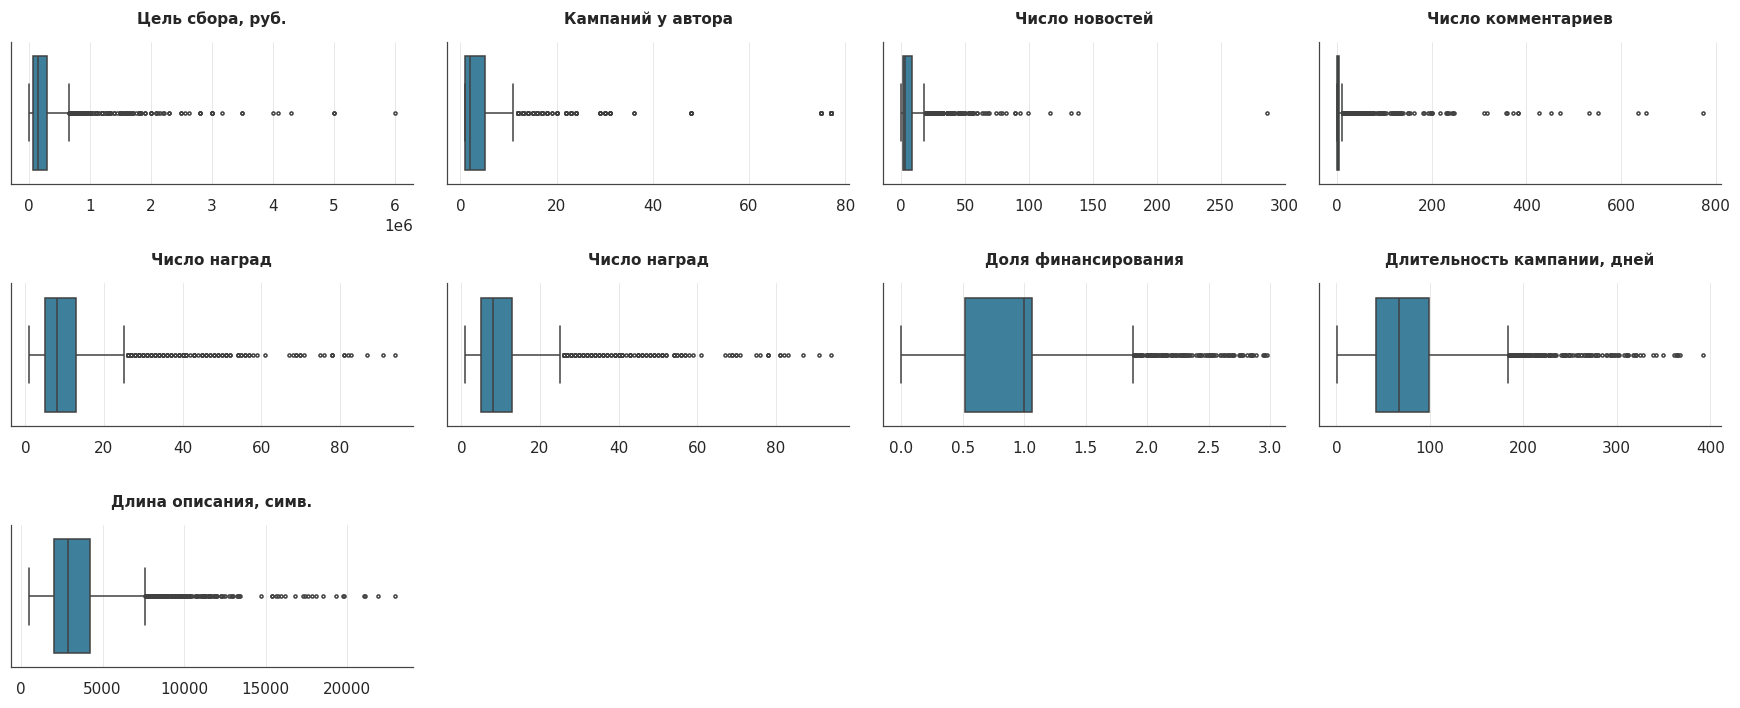

In [203]:
# Boxplots — сетка по всем числовым столбцам
n = len(numeric_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.2*nrows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=COLOR_PRIMARY, fliersize=2)
    axes[i].set_title(label(col), fontsize=10)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

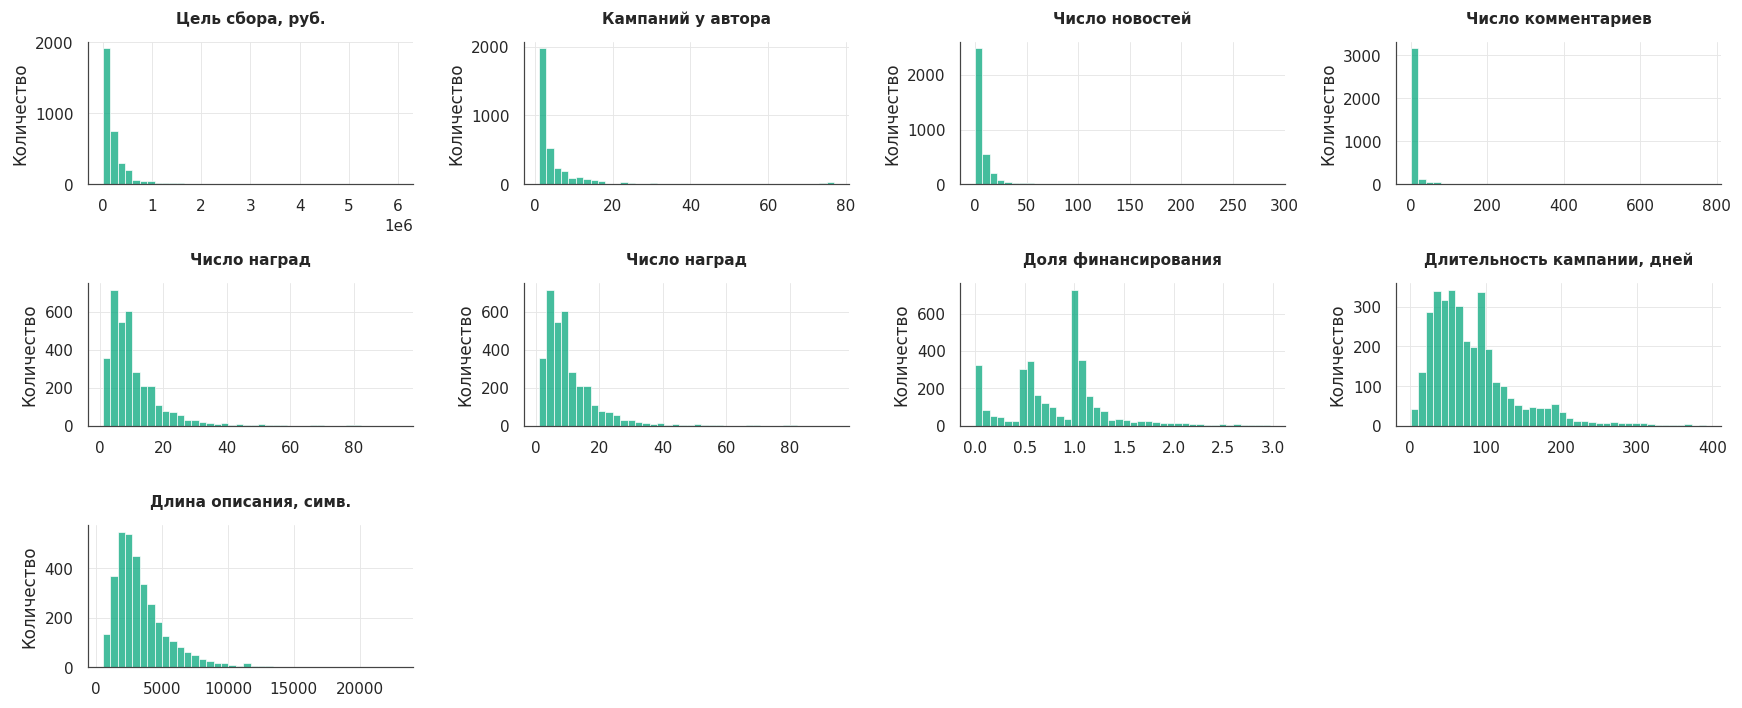

In [204]:
# Histograms — оцениваем асимметрию
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.2*nrows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], bins=40, color=COLOR_SUCCESS, kde=False)
    axes[i].set_title(label(col), fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

Сильно правоскошенных (skew>3, >=0): 6


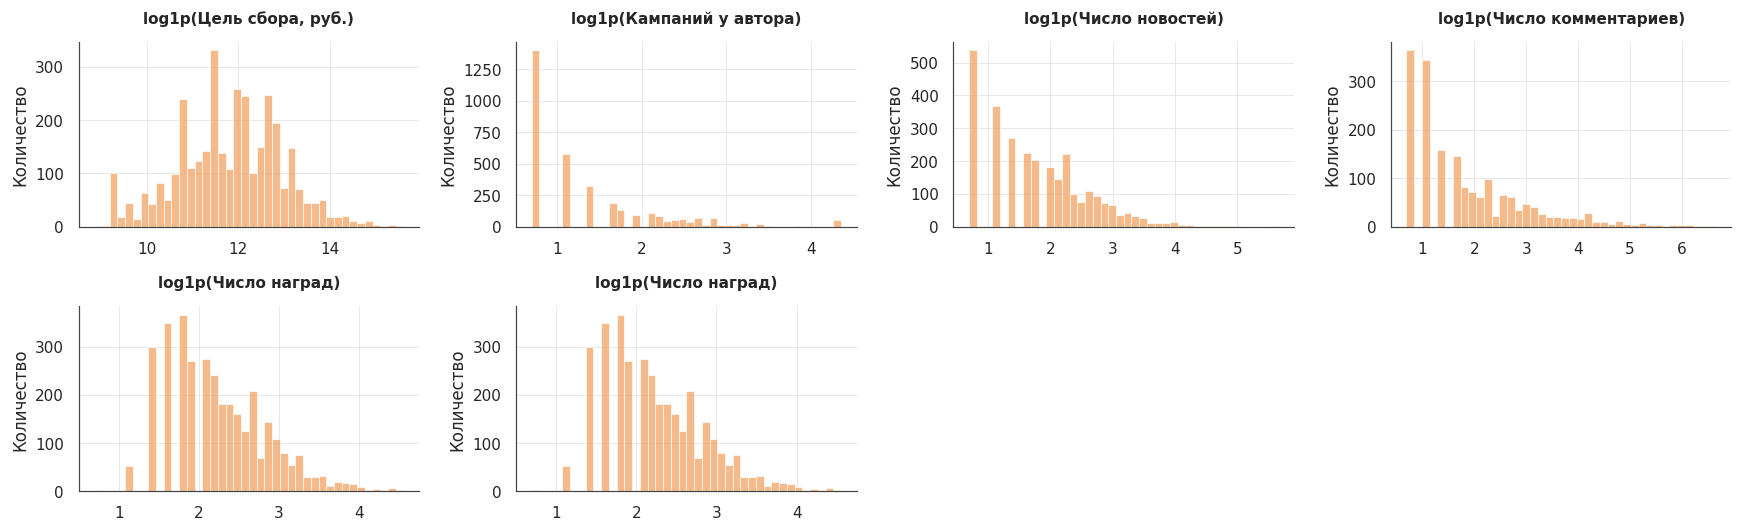

In [205]:
# Log-scale boxplots для сильно скошенных финансовых / счётчиков
skewed = [c for c in numeric_cols if df[c].skew() > 3 and (df[c] >= 0).all()]
print(f'Сильно правоскошенных (skew>3, >=0): {len(skewed)}')
if skewed:
    ncols2 = 4
    nrows2 = int(np.ceil(len(skewed)/ncols2))
    fig, axes = plt.subplots(nrows2, ncols2, figsize=(4*ncols2, 2.5*nrows2))
    axes = axes.flatten()
    for i, col in enumerate(skewed):
        vals = df[col].replace(0, np.nan).dropna()
        if len(vals) == 0:
            axes[i].axis('off')
            continue
        sns.histplot(np.log1p(vals), ax=axes[i], bins=40, color=COLOR_ACCENT)
        axes[i].set_title(f'log1p({label(col)})', fontsize=10)
        axes[i].set_xlabel('log(1 + значение)')
        axes[i].set_ylabel('Количество')
        axes[i].set_xlabel('')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

## 3. Правила бизнес-логики

Некоторые строки — очевидно битые: нулевая цель, отрицательные длительности, кампании длиннее года и т.д. Их помечаем до статистических тестов.

In [ ]:
rules = {}
# Все бизнес-фильтры применены в ручной чистке выше

rules_df = pd.DataFrame(rules)
print('Количество строк, нарушающих каждое правило:')
print(rules_df.sum().to_string())
print(f'\nВсего строк с хотя бы одним нарушением: {rules_df.any(axis=1).sum()}')

## 4. Идентификация выбросов: IQR-метод (Тьюки)

Порог `1.5·IQR` — мягкий (обычные выбросы), `3·IQR` — жёсткий (экстремальные). Используем **3·IQR**, чтобы не удалить слишком много валидных хвостовых наблюдений.

In [207]:
def iqr_outliers(series: pd.Series, k: float = 3.0) -> pd.Series:
    """Возвращает булеву маску выбросов по правилу Тьюки (k·IQR)."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(False, index=series.index)
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return (series < lower) | (series > upper)

iqr_mask = pd.DataFrame(
    {c: iqr_outliers(df[c], k=3.0) for c in numeric_cols},
    index=df.index
).fillna(False)

iqr_summary = iqr_mask.sum().sort_values(ascending=False)
iqr_summary = iqr_summary[iqr_summary > 0]
print('Топ столбцов по числу IQR-выбросов (3·IQR):')
print(iqr_summary.head(20).to_string())
print(f'\nВсего строк-выбросов по ≥1 столбцу: {iqr_mask.any(axis=1).sum()}')

Топ столбцов по числу IQR-выбросов (3·IQR):
counts.commentsCount           326
card.author.campaignsAmount    159
card.targetAmount.value        102
counts.newsCount                95
rewards.totalRewards            85
reward_count                    85
description_len_chars           59
campaign_duration_days          43
funding_ratio                   17

Всего строк-выбросов по ≥1 столбцу: 734


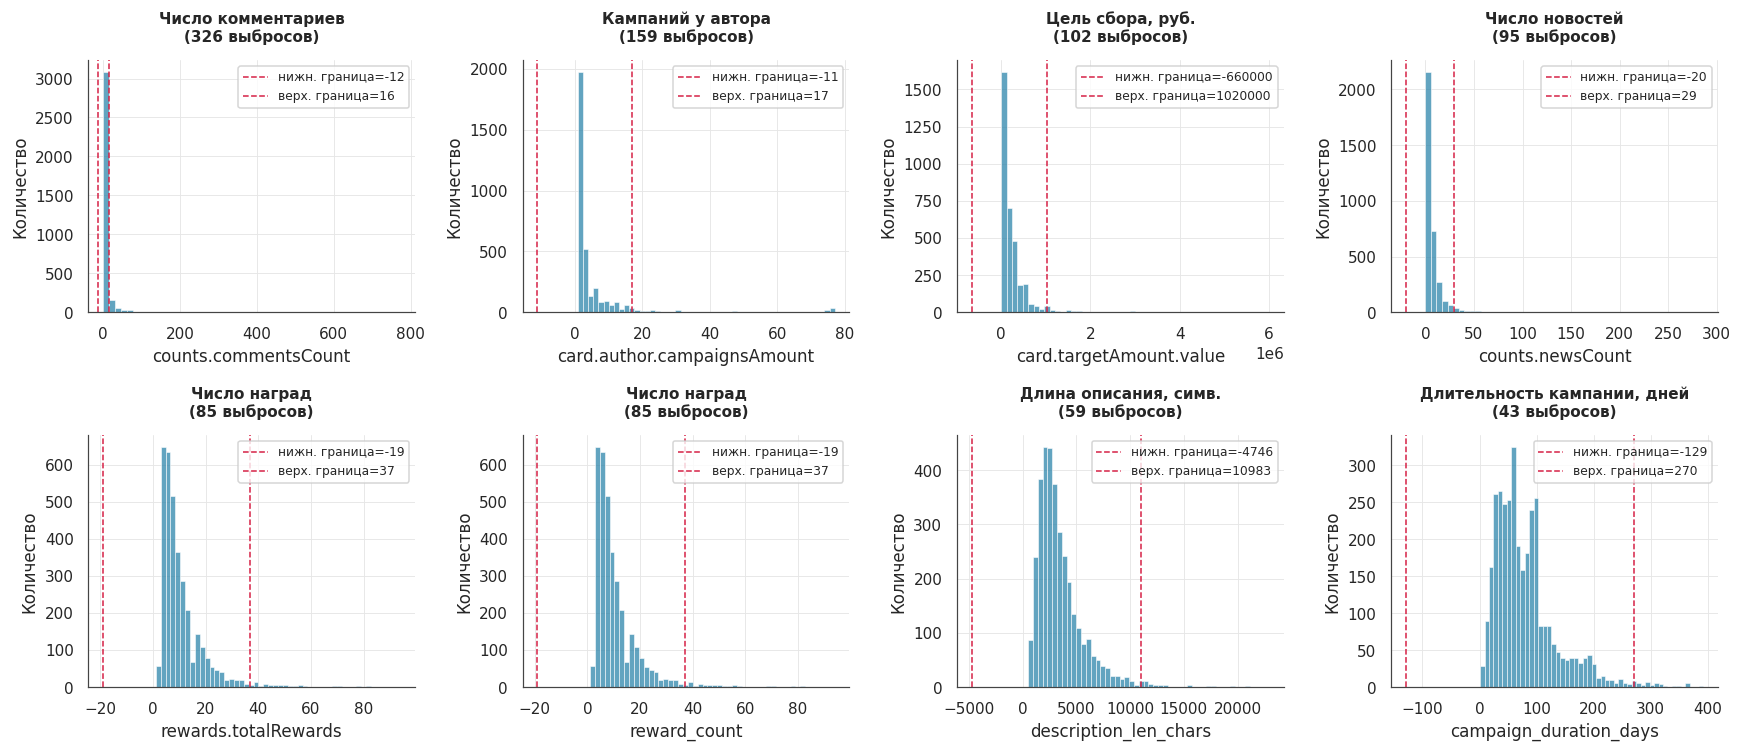

In [208]:
# Визуализируем топ-8 столбцов с максимумом выбросов
top8 = iqr_summary.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), top8):
    q1, q3 = df[col].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 3*iqr, q3 + 3*iqr
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color=COLOR_PRIMARY)
    ax.axvline(lo, color=COLOR_FAIL, ls='--', lw=1, label=f'нижн. граница={lo:.0f}')
    ax.axvline(hi, color=COLOR_FAIL, ls='--', lw=1, label=f'верх. граница={hi:.0f}')
    ax.set_title(f'{label(col)}\n({iqr_mask[col].sum()} выбросов)', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

## 5. Z-score (|z| > 3)

Дополнительный тест в предположении приближённой нормальности. Подсчитывается по каждому столбцу отдельно.

In [209]:
Z_THRESHOLD = 3.0
z_mask = pd.DataFrame(index=df.index)
for col in numeric_cols:
    s = df[col]
    mu, sigma = s.mean(), s.std(ddof=0)
    if sigma == 0 or np.isnan(sigma):
        z_mask[col] = False
    else:
        z_mask[col] = (np.abs((s - mu) / sigma) > Z_THRESHOLD).fillna(False)

z_summary = z_mask.sum().sort_values(ascending=False)
z_summary = z_summary[z_summary > 0]
print('Топ столбцов по числу Z-выбросов (|z|>3):')
print(z_summary.head(20).to_string())
print(f'\nВсего строк-выбросов по ≥1 столбцу: {z_mask.any(axis=1).sum()}')

Топ столбцов по числу Z-выбросов (|z|>3):
rewards.totalRewards           78
reward_count                   78
card.targetAmount.value        70
description_len_chars          64
campaign_duration_days         61
card.author.campaignsAmount    60
counts.newsCount               51
funding_ratio                  50
counts.commentsCount           45

Всего строк-выбросов по ≥1 столбцу: 411


## 6. Многомерный выброс: Isolation Forest

IQR и Z-score — покоординатные. Isolation Forest ловит строки, аномальные в **пространстве** всех признаков одновременно.

In [210]:
# Для IF используем подмножество числовых столбцов без NaN
X = df[numeric_cols].copy()
# Заполняем пропуски медианой (IF не толерантен к NaN)
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # ожидаем ~5% аномалий
    random_state=42,
    n_jobs=-1,
)
iso_pred = iso.fit_predict(X_scaled)
iso_score = iso.decision_function(X_scaled)

if_mask = pd.Series(iso_pred == -1, index=df.index, name='iso_forest_outlier')
print(f'Isolation Forest выделил {if_mask.sum()} аномалий ({if_mask.mean()*100:.1f}%)')

Isolation Forest выделил 172 аномалий (5.0%)


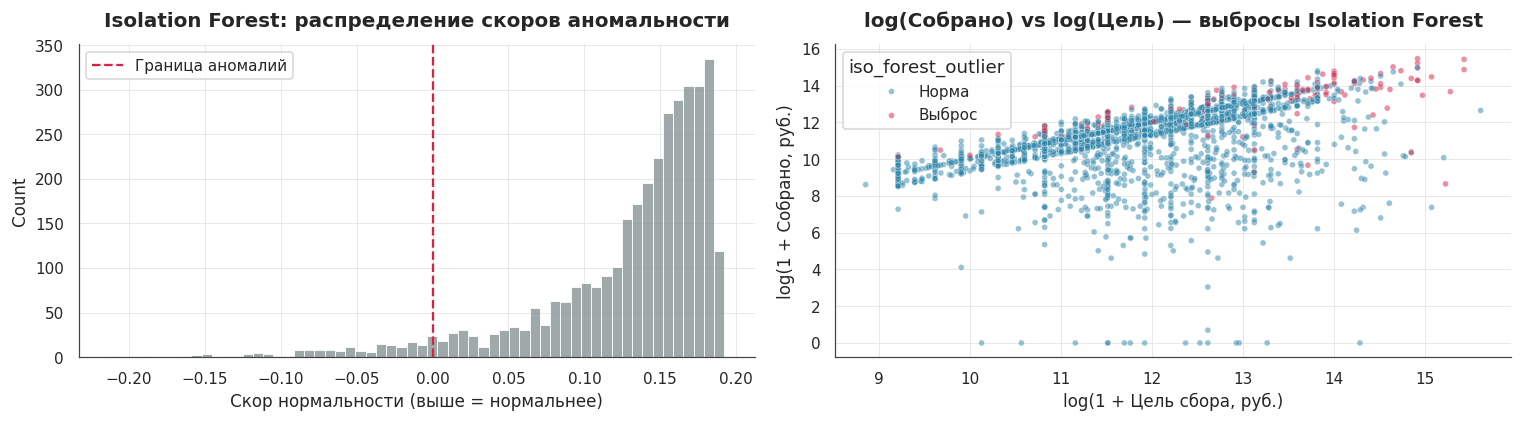

In [211]:
# Визуализация anomaly score
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(iso_score, bins=60, ax=ax[0], color=COLOR_NEUTRAL)
ax[0].axvline(iso_score[iso_pred == -1].max(), color=COLOR_FAIL, ls='--',
              label='Граница аномалий')
ax[0].set_title('Isolation Forest: распределение скоров аномальности')
ax[0].set_xlabel('Скор нормальности (выше = нормальнее)')
ax[0].legend()

# Scatter: collected vs target с подсветкой аномалий
sns.scatterplot(
    x=np.log1p(df['card.targetAmount.value']),
    y=np.log1p(df['card.collectedAmount.value']),
    hue=if_mask.map({True: 'Выброс', False: 'Норма'}),
    palette={'Выброс': COLOR_FAIL, 'Норма': COLOR_PRIMARY},
    alpha=0.5, s=15, ax=ax[1]
)
ax[1].set_title('log(Собрано) vs log(Цель) — выбросы Isolation Forest')
ax[1].set_xlabel('log(1 + Цель сбора, руб.)')
ax[1].set_ylabel('log(1 + Собрано, руб.)')
plt.tight_layout()
plt.show()

## 7. Сводный флаг `is_outlier`

Строка считается выбросом, если выполнено **хотя бы одно** из условий:
- нарушает бизнес-правило
- выброс по **≥2 столбцам** одновременно (IQR 3× ИЛИ Z>3) — одиночный выброс по одному столбцу часто не фатален
- помечена Isolation Forest

Такой подход сохраняет строки с единичным экстремумом, но убирает по-настоящему проблемные записи.

In [212]:
# Счётчики выбросов по каждой строке
n_iqr_flags = iqr_mask.sum(axis=1)
n_z_flags   = z_mask.sum(axis=1)
n_univar_flags = ((iqr_mask | z_mask).sum(axis=1))

rule_violation = rules_df.any(axis=1)
multi_univar   = n_univar_flags >= 2

is_outlier = rule_violation | multi_univar | if_mask

flags = pd.DataFrame({
    'rule_violation': rule_violation,
    'n_iqr_flags': n_iqr_flags,
    'n_z_flags':   n_z_flags,
    'n_univar_flags': n_univar_flags,
    'multi_univar':   multi_univar,
    'iso_forest':     if_mask,
    'is_outlier':     is_outlier,
}, index=df.index)

print('Распределение выбросов по источникам:')
print(f'  rule violations:        {rule_violation.sum():5d}')
print(f'  multi-univariate (≥2):  {multi_univar.sum():5d}')
print(f'  Isolation Forest:       {if_mask.sum():5d}')
print(f'  ----------------------------')
print(f'  итоговый is_outlier:    {is_outlier.sum():5d} ({is_outlier.mean()*100:.1f}%)')

Распределение выбросов по источникам:
  rule violations:            2
  multi-univariate (≥2):    183
  Isolation Forest:         172
  ----------------------------
  итоговый is_outlier:      237 (6.9%)


In [213]:
# Пересечения методов
from itertools import combinations
sources = {'rule': rule_violation, 'multi_univar': multi_univar, 'iso': if_mask}
print('Попарные пересечения:')
for a, b in combinations(sources, 2):
    inter = (sources[a] & sources[b]).sum()
    print(f'  {a} ∩ {b}: {inter}')
print(f'  все три одновременно: {(rule_violation & multi_univar & if_mask).sum()}')

Попарные пересечения:
  rule ∩ multi_univar: 1
  rule ∩ iso: 1
  multi_univar ∩ iso: 119
  все три одновременно: 1


/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_65358/1870795547.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y='value', ax=ax,
/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_65358/1870795547.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y='value', ax=ax,
/var/folders/2l/n72xwmrs7sv8qw6zsw6flx4w0000gn/T/ipykernel_65358/1870795547.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y='value', ax=ax,


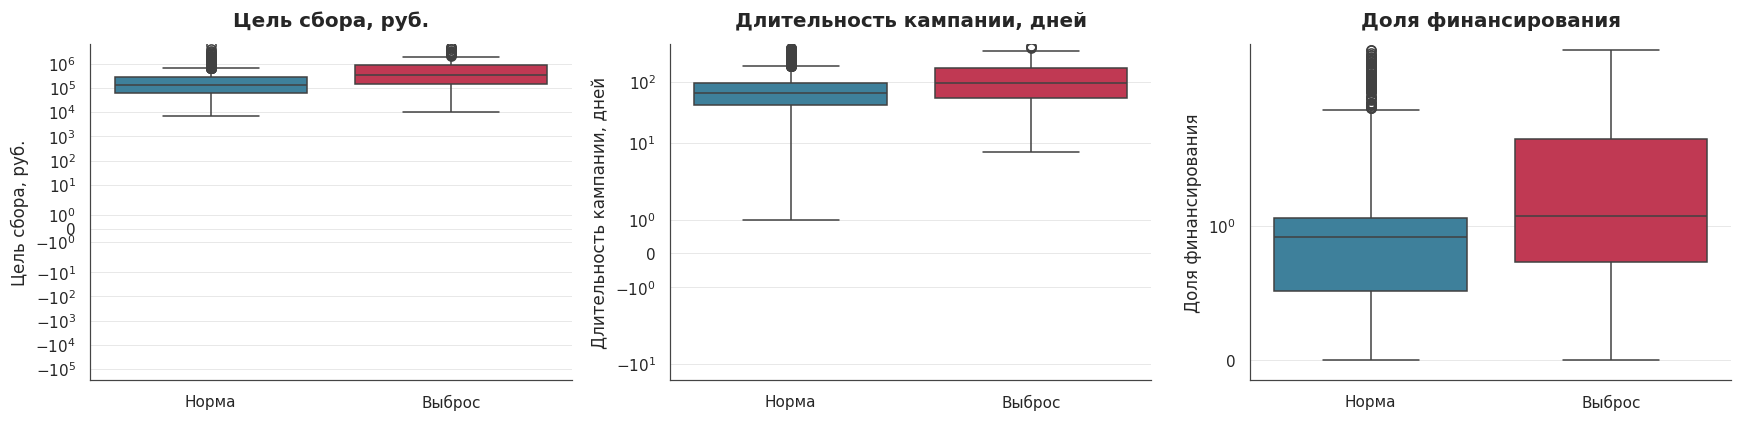

In [214]:
# Визуализация: кого выбрасываем
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['card.targetAmount.value',
                          'campaign_duration_days',
                          'funding_ratio']):
    data = pd.DataFrame({
        'value': df[col],
        'status': np.where(is_outlier, 'Выброс', 'Норма')
    })
    sns.boxplot(data=data, x='status', y='value', ax=ax,
                palette={'Норма': COLOR_PRIMARY, 'Выброс': COLOR_FAIL})
    ax.set_yscale('symlog')
    ax.set_title(label(col))
    ax.set_ylabel(label(col))
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [215]:
# Доля успешных кампаний до/после чистки — контроль, что не уничтожили таргет
before = df['is_successful'].mean()
after  = df.loc[~is_outlier, 'is_successful'].mean()
print(f'is_successful: до = {before:.3f}, после = {after:.3f} '
      f'(Δ = {(after-before)*100:+.1f} п.п.)')

# Распределение категорий до/после
cat_before = df['category_grouped'].value_counts(normalize=True).round(3)
cat_after  = df.loc[~is_outlier, 'category_grouped'].value_counts(normalize=True).round(3)
cat_comp = pd.DataFrame({'before': cat_before, 'after': cat_after}).fillna(0)
cat_comp['delta_pp'] = ((cat_comp['after'] - cat_comp['before']) * 100).round(2)
cat_comp.sort_values('before', ascending=False)

is_successful: до = 0.506, после = 0.492 (Δ = -1.4 п.п.)


,before,after,delta_pp
category_grouped,,,
Благотворительность,0.302,0.311,0.9
Музыка,0.183,0.176,-0.7
Литература,0.174,0.177,0.3
"Творческие (кино, театр, дизайн)",0.148,0.142,-0.6
Социальные,0.092,0.090,-0.2
Досуг и события,0.057,0.059,0.2
Образование и просвещение,0.029,0.028,-0.1
Технологии,0.009,0.009,0.0
Бизнес,0.008,0.008,0.0


## 8. Сохранение результатов

In [216]:
df_clean    = df.loc[~is_outlier].copy()
df_outliers = df.loc[is_outlier].copy()

# К выбросам добавляем флаги — зачем строка была исключена
df_outliers = pd.concat([df_outliers, flags.loc[is_outlier]], axis=1)
# Какие именно правила нарушены
rules_out = rules_df.loc[is_outlier].copy()
rules_out.columns = ['rule_' + c for c in rules_out.columns]
df_outliers = pd.concat([df_outliers, rules_out], axis=1)

df_clean.to_excel(OUTPUT_CLEAN, index=False)
df_outliers.to_excel(OUTPUT_OUTLIERS, index=False)

print(f'✓ Очищенный датасет:   {OUTPUT_CLEAN}  ({df_clean.shape[0]} строк, {df_clean.shape[1]} колонок)')
print(f'✓ Датасет с выбросами: {OUTPUT_OUTLIERS}  ({df_outliers.shape[0]} строк, {df_outliers.shape[1]} колонок)')
print(f'  удалено {is_outlier.sum()} из {len(df)} строк ({is_outlier.mean()*100:.1f}%)')

✓ Очищенный датасет:   projects_planeta_cleaned.xlsx  (3192 строк, 40 колонок)
✓ Датасет с выбросами: projects_planeta_with_text_outliers.xlsx  (237 строк, 50 колонок)
  удалено 237 из 3429 строк (6.9%)


In [217]:
# Сравнение описательных статистик до/после
compare_cols = ['card.collectedAmount.value', 'card.targetAmount.value',
                'funding_ratio', 'campaign_duration_days',
                'counts.participantsCount', 'description_len_chars']
before_stats = df[compare_cols].describe().round(2)
after_stats  = df_clean[compare_cols].describe().round(2)
print('=== ДО ===')
print(before_stats.to_string())
print('\n=== ПОСЛЕ ===')
print(after_stats.to_string())

=== ДО ===
       card.collectedAmount.value  card.targetAmount.value  funding_ratio  campaign_duration_days  counts.participantsCount  description_len_chars
count                     3429.00                  3429.00        3429.00                 3429.00                   3429.00                3429.00
mean                    180911.47                253623.83           0.84                   80.94                    102.94                3505.74
std                     311891.96                389111.70           0.50                   55.47                    180.06                2355.49
min                          0.00                  7000.00           0.00                    1.00                      0.00                 506.00
25%                      33055.00                 60000.00           0.52                   42.00                     23.00                1995.00
50%                      90200.00                149600.00           1.00                   67.00          

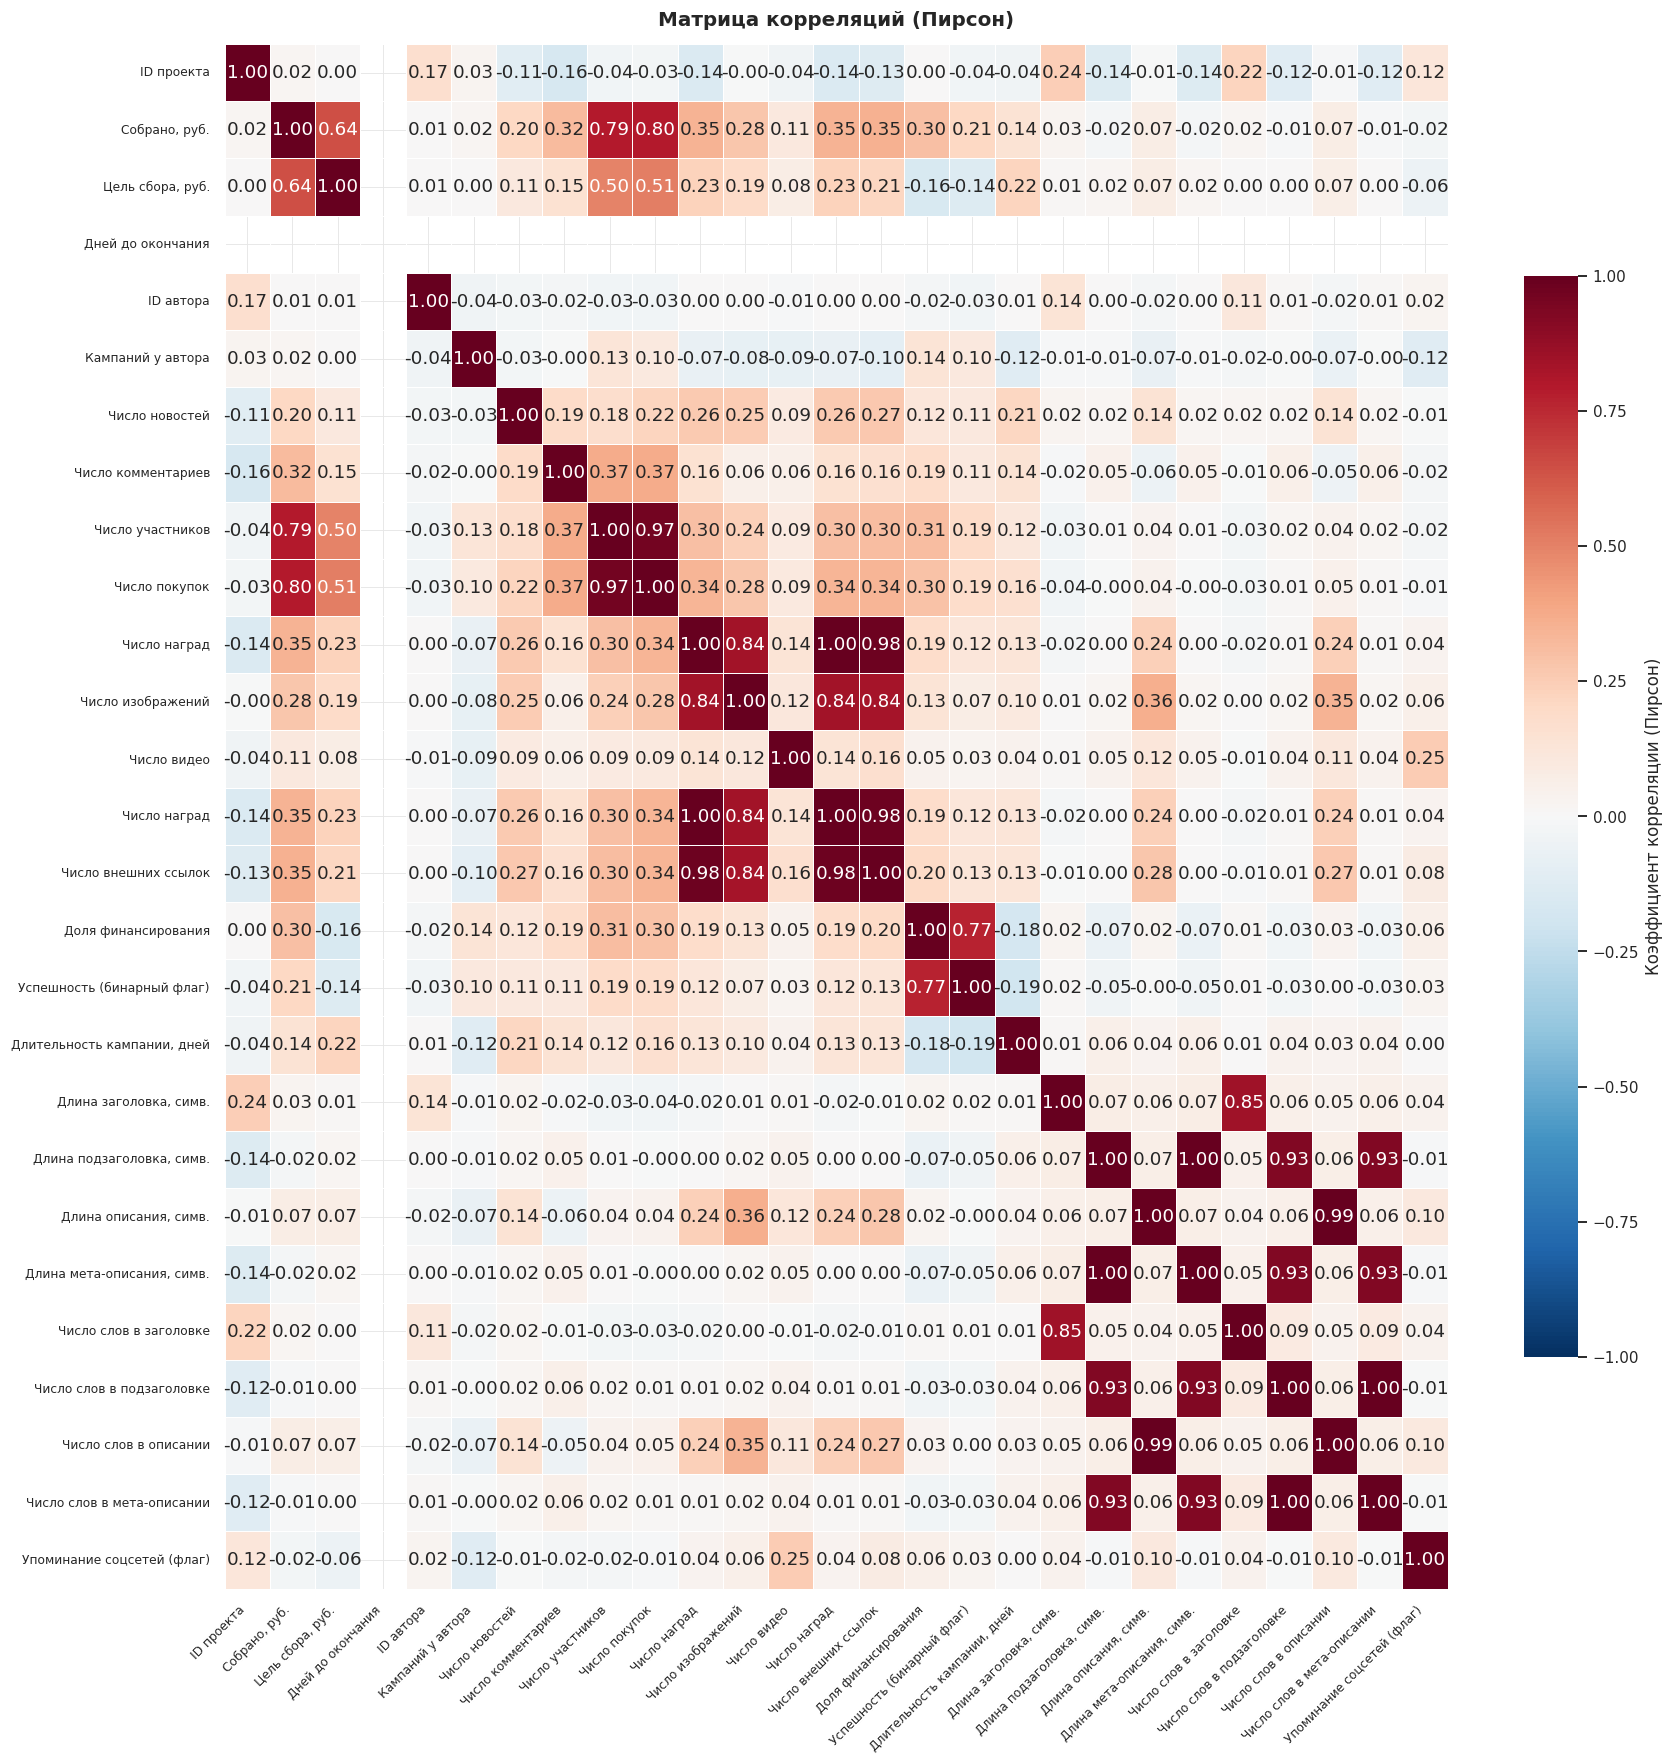

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_m = df.corr(numeric_only=True)
rus_labels = [label(c) for c in corr_m.columns]
fig_h, ax_h = plt.subplots(figsize=(max(12, len(corr_m)*0.6), max(10, len(corr_m)*0.6)))
sns.heatmap(
    corr_m,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    xticklabels=rus_labels, yticklabels=rus_labels,
    cbar_kws={'label': 'Коэффициент корреляции (Пирсон)', 'shrink': 0.7},
    ax=ax_h
)
ax_h.set_title('Матрица корреляций (Пирсон)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()
